<h1>Workflow</h1>

<pre>Import important libraries<br>
Get data ready (turn into tensors)<br>
Built a LinearRegression model<br>
Pick a loss function and optimizer<br>
Build a training loop<br>
Evaluate your model<br>
Test modrl with a new data point<br>
Save the model</pre>

<h2>Import important libraries</h2>

In [272]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<h3>Get Data ready (turn into tensors)</h3>

In [273]:
df = pd.read_csv("practice.csv")
df

,Hours Studied (x_train),Exam Score (y_train)
0,3.300,1.700
1,4.400,2.760
2,5.500,2.090
3,6.710,3.190
4,6.930,1.694
5,4.168,1.573
6,9.779,3.366
7,6.182,2.596
8,7.590,2.530
9,2.167,1.221


In [274]:
x_train = df.drop("Exam Score (y_train)",axis=1)
x_train

,Hours Studied (x_train)
0,3.300
1,4.400
2,5.500
3,6.710
4,6.930
5,4.168
6,9.779
7,6.182
8,7.590
9,2.167


In [275]:
y_train = df.drop("Hours Studied (x_train)",axis=1)
y_train

,Exam Score (y_train)
0,1.700
1,2.760
2,2.090
3,3.190
4,1.694
5,1.573
6,3.366
7,2.596
8,2.530
9,1.221


<h3>Convert into numpy array</h3>

In [276]:
x_train = x_train.to_numpy()
x_train

array([[ 3.3  ],
       [ 4.4  ],
       [ 5.5  ],
       [ 6.71 ],
       [ 6.93 ],
       [ 4.168],
       [ 9.779],
       [ 6.182],
       [ 7.59 ],
       [ 2.167],
       [ 7.042],
       [10.791],
       [ 5.313],
       [ 7.997],
       [ 3.1  ]])

In [277]:
y_train = y_train.to_numpy()
y_train, y_train.dtype

(array([[1.7  ],
        [2.76 ],
        [2.09 ],
        [3.19 ],
        [1.694],
        [1.573],
        [3.366],
        [2.596],
        [2.53 ],
        [1.221],
        [2.827],
        [3.465],
        [1.65 ],
        [2.904],
        [1.3  ]]),
 dtype('float64'))

<h3>Plot into pyplot</h3>

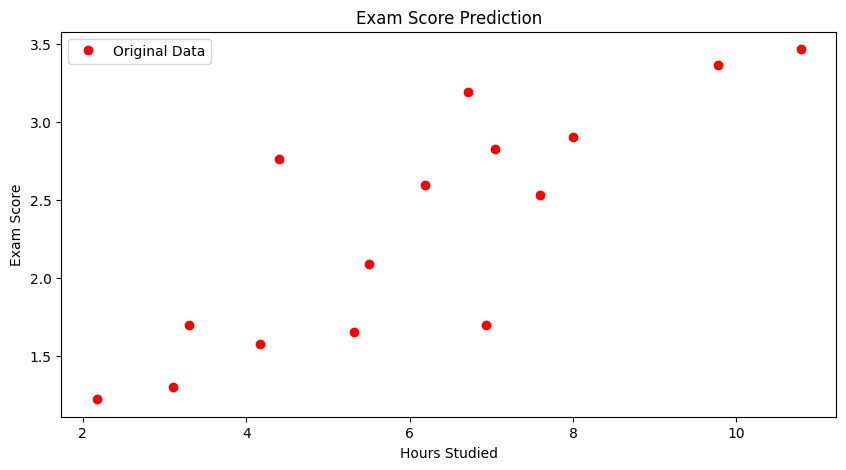

In [278]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_train,y_train,'ro',label='Original Data')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.title('Exam Score Prediction')
plt.show()

<h3>Convert into pytorch tensor</h3>

In [279]:
x_train = torch.from_numpy(x_train)
y_train = torch.from_numpy(y_train)

In [280]:
x_train, y_train

(tensor([[ 3.3000],
         [ 4.4000],
         [ 5.5000],
         [ 6.7100],
         [ 6.9300],
         [ 4.1680],
         [ 9.7790],
         [ 6.1820],
         [ 7.5900],
         [ 2.1670],
         [ 7.0420],
         [10.7910],
         [ 5.3130],
         [ 7.9970],
         [ 3.1000]], dtype=torch.float64),
 tensor([[1.7000],
         [2.7600],
         [2.0900],
         [3.1900],
         [1.6940],
         [1.5730],
         [3.3660],
         [2.5960],
         [2.5300],
         [1.2210],
         [2.8270],
         [3.4650],
         [1.6500],
         [2.9040],
         [1.3000]], dtype=torch.float64))

In [281]:
x_train = x_train.type(torch.FloatTensor) #to change into 32-bit
y_train = y_train.type(torch.FloatTensor)

<h3>Using the type() method:</h3>
<p>
x = x.type(torch.FloatTensor) <br>

torch.FloatTesor = torch.float32 <br> 
torch.DoubleTensor = torch.float64 <br>
torch.IntTensor = torch.int32 <br>
</p>


<h3>Using the to() method:</h3>
<p>
x = x.to(torch.float16) <br>
</p>

<h3>2 .Build a Linear Regresson model</h3>

In [282]:
class LinearRegresson(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1,1)
    def forward(self,x):
        out = self.linear(x)
        return out

In [283]:
model = LinearRegresson()

In [284]:
model

LinearRegresson(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [285]:
list(model.parameters())

[Parameter containing:
 tensor([[0.1753]], requires_grad=True),
 Parameter containing:
 tensor([0.9602], requires_grad=True)]

In [286]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.1753]])),
             ('linear.bias', tensor([0.9602]))])

w*x + b <br>
x = 3.3000, w = 0.6205 b = 0.6247

<h3>3. Pick a loss Function and Optimizer</h3>

In [287]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-4) #0.0001

<h3>4. Build a training loop</h3>

In [288]:
num_epochs = 1000

In [289]:
for epoch in range(num_epochs):
    model.train()
    out = model(x_train) #forward pass
    loss = criterion(out, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch +1) % 20 == 0:
        print(f"Epoch: [{epoch+1} / {num_epochs}], loss: {loss.item():.6f}")

Epoch: [20 / 1000], loss: 0.264386
Epoch: [40 / 1000], loss: 0.238243
Epoch: [60 / 1000], loss: 0.219765
Epoch: [80 / 1000], loss: 0.206704
Epoch: [100 / 1000], loss: 0.197472
Epoch: [120 / 1000], loss: 0.190945
Epoch: [140 / 1000], loss: 0.186330
Epoch: [160 / 1000], loss: 0.183066
Epoch: [180 / 1000], loss: 0.180758
Epoch: [200 / 1000], loss: 0.179125
Epoch: [220 / 1000], loss: 0.177968
Epoch: [240 / 1000], loss: 0.177149
Epoch: [260 / 1000], loss: 0.176569
Epoch: [280 / 1000], loss: 0.176156
Epoch: [300 / 1000], loss: 0.175863
Epoch: [320 / 1000], loss: 0.175654
Epoch: [340 / 1000], loss: 0.175504
Epoch: [360 / 1000], loss: 0.175397
Epoch: [380 / 1000], loss: 0.175319
Epoch: [400 / 1000], loss: 0.175262
Epoch: [420 / 1000], loss: 0.175219
Epoch: [440 / 1000], loss: 0.175188
Epoch: [460 / 1000], loss: 0.175164
Epoch: [480 / 1000], loss: 0.175145
Epoch: [500 / 1000], loss: 0.175129
Epoch: [520 / 1000], loss: 0.175117
Epoch: [540 / 1000], loss: 0.175106
Epoch: [560 / 1000], loss: 0.175

<h3>5 Evaluate the model</h3>

In [290]:
model.eval()
with torch.no_grad():
    prediction = model(x_train)
prediction.data.numpy()

array([[1.7184185],
       [1.9704732],
       [2.222528 ],
       [2.499788 ],
       [2.5501988],
       [1.9173126],
       [3.2030206],
       [2.3788018],
       [2.7014318],
       [1.4588022],
       [2.5758626],
       [3.434911 ],
       [2.1796787],
       [2.794692 ],
       [1.6725904]], dtype=float32)

In [291]:
y_train

tensor([[1.7000],
        [2.7600],
        [2.0900],
        [3.1900],
        [1.6940],
        [1.5730],
        [3.3660],
        [2.5960],
        [2.5300],
        [1.2210],
        [2.8270],
        [3.4650],
        [1.6500],
        [2.9040],
        [1.3000]])

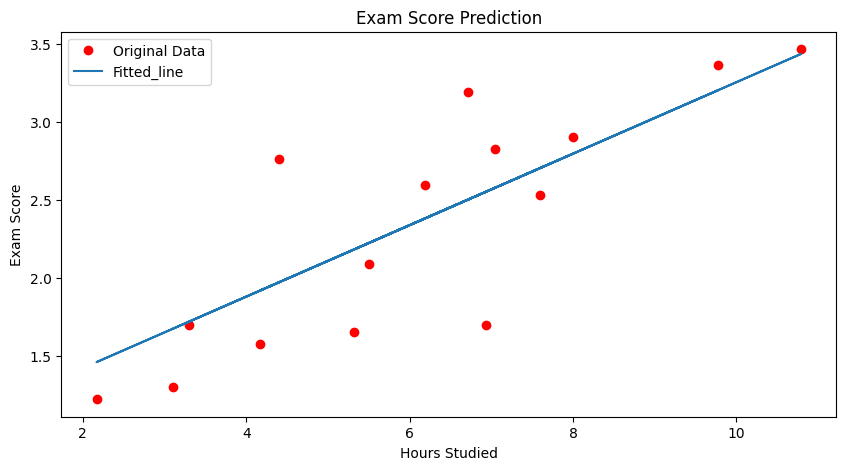

In [292]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_train.numpy(),y_train.numpy(),'ro',label='Original Data')
plt.plot(x_train.numpy(),prediction,label='Fitted_line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.title('Exam Score Prediction')
plt.show()

In [293]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.2291]])),
             ('linear.bias', tensor([0.9623]))])

<h3>Test the model with the new datapoint</h3>

In [294]:
new_data = 8.0
new_hours_tensor = torch.tensor([[new_data]], dtype = torch.float32)

In [295]:
model.eval()
with torch.no_grad():
    new_exam_score = model(new_hours_tensor)
print(f"Predicted exam score: {new_exam_score.item()}")

Predicted exam score: 2.795379400253296


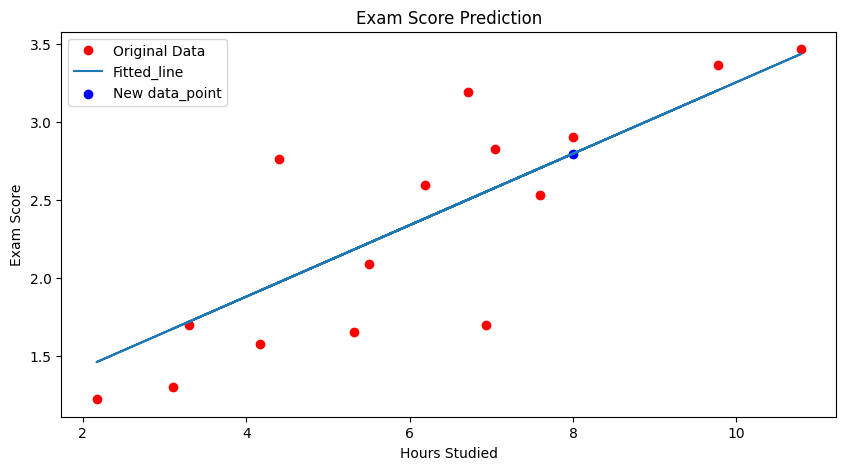

In [296]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_train.numpy(),y_train.numpy(),'ro',label='Original Data')
plt.plot(x_train.numpy(),prediction,label='Fitted_line')
plt.scatter([new_data],[new_exam_score.item()],color='blue',label='New data_point')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.title('Exam Score Prediction')
plt.show()

<h3>Sava the model</h3>

In [297]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.2291]])),
             ('linear.bias', tensor([0.9623]))])

In [298]:
torch.save(model.state_dict(),"./LinearRegression.pth")